In [205]:
import torch
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from pfns.bar_distribution import FullSupportBarDistribution

from tfmplayground import NanoTabPFNClassifier
from tfmplayground import NanoTabPFNRegressor
from tfmplayground.models.nanotabpfn import NanoTabPFNModel

In [206]:
# Initialize a classifier
model = NanoTabPFNModel(
    num_attention_heads=6,
    embedding_size=192,
    mlp_hidden_size=768,
    num_layers=6,
    num_outputs=100,
)
model.load_state_dict(
    torch.load("/data/PFN/Mouse/pretrained_mousepfn.pth")
)
bucket_edges = torch.load("/data/PFN/Mouse/buckets_mousepfn.pth")
dist = FullSupportBarDistribution(bucket_edges)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

reg = NanoTabPFNRegressor(
    model=model,
    dist=dist,
    device=device,
)

# Load data
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

clf = NanoTabPFNClassifier(
    model=model,
)
clf.fit(X_train, y_train)

# Predict probabilities
prediction_probabilities = clf.predict_proba(X_test)
print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))

# Predict labels
predictions = clf.predict(X_test)
print("Accuracy", accuracy_score(y_test, predictions))

(512, 30) (512,)
(57, 30) (57,)
ROC AUC: 0.7970588235294118
Accuracy 0.2982456140350877


In [207]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabpfn_time_series import (
    FeatureTransformer,
    TabPFNMode,
    TabPFNTimeSeriesPredictor,
    TabPFNTSPipeline,
    TimeSeriesDataFrame,
)
from tabpfn_time_series.features import (
    AutoSeasonalFeature,
    CalendarFeature,
    RunningIndexFeature,
)
from tabpfn_time_series.plot import plot_forecast

pd.set_option("display.max_rows", 1000)

In [208]:
DATAPATH = "/data/PFN/Mouse/"
FILE = "data_v4.csv"
VERSUCHSREIHE = [3, 7, 10, 12, 15]
NUM_SERIES = 4000
NUM_TEST_SERIES = 4000
PREDICTION_LENGTH = 4

In [209]:
df = pd.read_csv(os.path.join(DATAPATH, FILE))

# df = df[df["Versuchsreihe"].isin(VERSUCHSREIHE)].drop(columns=["Versuchsreihe"]).reset_index(drop=True)
df = df[df["Versuchsreihe"].isin(VERSUCHSREIHE)].reset_index(drop=True)

# Filter animals that have less than PREDICTION_LENGTH + 1 measurements
df = df.groupby("IdTier").filter(lambda x: len(x) > PREDICTION_LENGTH + 1).reset_index(drop=True)

# Filter animals that have values that are not possible < 5 or > 60
df = df.groupby("IdTier").filter(lambda x: (x["Gewicht"] > 5).all() and (x["Gewicht"] < 60).all()).reset_index(drop=True)

df["IdTier"] = df["IdTier"].astype("category").cat.codes.astype(int)

# Limit df to NUM_SERIES animals for now
NUM_SERIES = min(NUM_SERIES, df["IdTier"].nunique())
selected_ids = np.random.choice(df["IdTier"].unique(), size=NUM_SERIES, replace=False)
df = df[df["IdTier"].isin(selected_ids)].reset_index(drop=True)

# Ensure it is sorted
df = df.sort_values(["IdTier", "Datum"]).reset_index(drop=True)

# Rename to item_id, timestamp, target
df = df.rename(columns={"IdTier": "item_id", "Datum": "timestamp", "Gewicht": "target"})

df

,Versuchsreihe,Todesursache,item_id,timestamp,Age,Intervention,Bestrahlungen,Chemotherapie,Operationen,target
0,3,1,0,2013-06-24 15:00:00,86,0,0,0,0,24.5
1,3,1,0,2013-06-27 10:15:00,89,0,0,0,0,24.4
2,3,1,0,2013-07-01 08:30:00,93,0,0,0,0,24.7
3,3,1,0,2013-07-05 17:50:00,97,0,0,0,0,24.4
4,3,1,0,2013-07-05 17:50:00,97,0,0,0,0,29.5
...,...,...,...,...,...,...,...,...,...,...
19843,15,0,704,2022-03-04 07:05:00,106,0,0,0,0,29.8
19844,15,0,704,2022-03-05 07:14:00,107,0,0,0,0,28.4
19845,15,0,704,2022-03-06 07:14:00,108,0,0,0,0,27.9
19846,15,0,704,2022-03-07 07:14:00,109,0,0,0,0,27.1


In [210]:
# TEMPORARY: Filter out animals with less than 20 measurements
df = df.groupby("item_id").filter(lambda x: len(x) >= 20).reset_index(drop=True)

# And have atleast one intervention
df = df.groupby("item_id").filter(lambda x: (x["Intervention"] == 1).any()).reset_index(drop=True)

In [211]:
# Take last PREDICTION_LENGTH rows as test_df, rest as context_df
NUM_TEST_SERIES = min(NUM_TEST_SERIES, df["item_id"].nunique())
selected_ids = np.random.choice(df["item_id"].unique(), size=NUM_TEST_SERIES, replace=False)
test_df = df[df["item_id"].isin(selected_ids)].groupby("item_id").tail(PREDICTION_LENGTH)
# test_df = df.groupby("item_id").tail(PREDICTION_LENGTH)
context_df = df.drop(test_df.index)
future_df = test_df.drop(columns=["target"]).copy()

# Reset index for all DataFrames
context_df = context_df.reset_index(drop=True)
future_df = future_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Copy item_id as new column "IdTier"
context_df["IdTier"] = context_df["item_id"]
future_df["IdTier"] = future_df["item_id"]
test_df["IdTier"] = test_df["item_id"]

base_columns = ["item_id", "timestamp", "target"]
covariate_columns = ["IdTier", "Age", "Intervention"]

context_df = context_df[base_columns + covariate_columns]
future_df = future_df[base_columns[:2] + covariate_columns]
test_df = test_df[base_columns + covariate_columns]

context_df

,item_id,timestamp,target,IdTier,Age,Intervention
0,2,2013-06-24 15:00:00,27.0,2,196,0
1,2,2013-06-27 10:15:00,27.2,2,199,0
2,2,2013-07-01 08:30:00,27.3,2,203,0
3,2,2013-07-05 17:50:00,27.1,2,207,0
4,2,2013-07-08 09:50:00,27.4,2,210,0
...,...,...,...,...,...,...
10245,700,2022-03-28 07:02:00,34.2,700,130,0
10246,700,2022-03-29 06:56:00,34.0,700,131,0
10247,700,2022-03-30 07:00:00,33.7,700,132,0
10248,700,2022-03-31 06:58:00,32.7,700,133,0


In [212]:
# Causes of death
causes_of_death = df.groupby("item_id").nth(0).reset_index()[["item_id", "Todesursache"]]

# Therapy types:
# 0: No therapy
# 1: Radiation therapy (Bestrahlungen) only
# 2: Chemotherapy (Chemotherapie) only
# 3: Surgery (Operationen) only
# 4: Combination of therapies
# Get sum of columns "Bestrahlungen", "Chemotherapie", "Operationen" for each item_id
def determine_therapy_type(row):
    if row["Bestrahlungen"] == 0 and row["Chemotherapie"] == 0 and row["Operationen"] == 0:
        return 0
    elif row["Bestrahlungen"] > 0 and row["Chemotherapie"] == 0 and row["Operationen"] == 0:
        return 1
    elif row["Bestrahlungen"] == 0 and row["Chemotherapie"] > 0 and row["Operationen"] == 0:
        return 2
    elif row["Bestrahlungen"] == 0 and row["Chemotherapie"] == 0 and row["Operationen"] > 0:
        return 3
    else:
        return 4

therapy_type = df.groupby("item_id")[["Bestrahlungen", "Chemotherapie", "Operationen"]].sum().reset_index()
therapy_type["type"] = therapy_type.apply(determine_therapy_type, axis=1)

# Info dataframe Versuchsreihe, causes_of_death and therapy_type
info_df = df.groupby("item_id").nth(0).reset_index()[["item_id", "Versuchsreihe"]].merge(
    causes_of_death, on="item_id"
).merge(
    therapy_type[["item_id", "type"]], on="item_id"
)

info_df

,item_id,Versuchsreihe,Todesursache,type
0,2,3,1,1
1,3,3,1,4
2,5,3,1,2
3,7,3,1,2
4,8,3,1,1
5,9,3,1,2
6,11,3,1,2
7,12,3,1,4
8,14,3,1,4
9,15,3,1,1


In [213]:
context_df = TimeSeriesDataFrame(context_df)
future_df["target"] = np.nan
future_df = TimeSeriesDataFrame(future_df)

In [214]:
selected_features = [
    RunningIndexFeature(),
    # CalendarFeature(),
    # AutoSeasonalFeature(),
]

feature_transformer = FeatureTransformer(selected_features)

train_tsdf, test_tsdf = feature_transformer.transform(context_df, future_df)

train_tsdf = train_tsdf.droplevel("timestamp")
test_tsdf = test_tsdf.droplevel("timestamp")

train_tsdf = train_tsdf[["IdTier", "running_index", "Intervention", "target"]]
test_tsdf = test_tsdf[["IdTier", "running_index", "Intervention", "target"]]

first_item_id = test_tsdf.index[0]
print(train_tsdf.loc[first_item_id])
print(test_tsdf.loc[first_item_id])
print(test_df[test_df["item_id"] == first_item_id])

         IdTier  running_index  Intervention  target
item_id                                             
2             2              0             0    27.0
2             2              1             0    27.2
2             2              2             0    27.3
2             2              3             0    27.1
2             2              4             0    27.4
2             2              5             0    26.9
2             2              6             0    27.5
2             2              7             0    27.1
2             2              8             0    27.8
2             2              9             0    28.0
2             2             10             0    28.0
2             2             11             0    32.5
2             2             12             0    28.9
2             2             13             0    29.0
2             2             14             0    29.5
2             2             15             0    29.4
2             2             16             0  

Selected IdTier: 527
Prediction: [20.765398 20.688068 20.595438 20.492018]
Ground truth: [21.35 21.35 21.35 21.15]


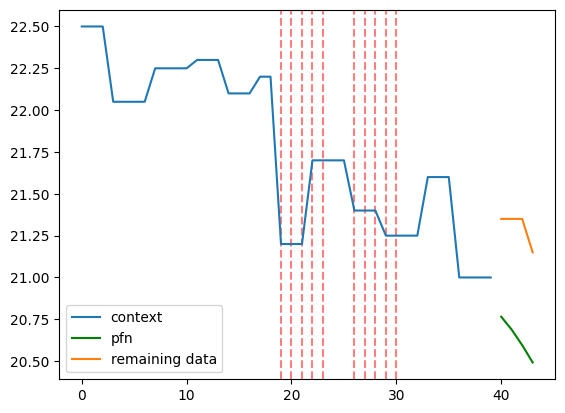

In [273]:
id_tier = np.random.choice(train_tsdf["IdTier"].unique())
print(f"Selected IdTier: {id_tier}")
versuchsreihe_mouse = info_df[info_df["item_id"] == id_tier]["Versuchsreihe"].values[0]

# Select 20 mice from the same Versuchsreihe but not id_tier
similar_mice = info_df[(info_df["Versuchsreihe"] == versuchsreihe_mouse) & (info_df["item_id"] != id_tier)]["item_id"].unique()
similar_mice = np.random.choice(similar_mice, size=min(30, len(similar_mice)), replace=False)

# similar_mice dataframe contains all data for the selected mice from train_tsdf, test_tsdf and test_df
similar_mice_train_df = train_tsdf[train_tsdf["IdTier"].isin(similar_mice)]
similar_mice_test_tsdf = test_tsdf[test_tsdf["IdTier"].isin(similar_mice)]

for mouse in similar_mice:
    similar_mice_test_tsdf.loc[mouse, "target"] = test_df[test_df["item_id"] == mouse]["target"].values

combined_similar_mice_df = pd.concat([similar_mice_train_df, similar_mice_test_tsdf], ignore_index=True)
combined_similar_mice_df = combined_similar_mice_df.sort_values(["IdTier", "running_index"]).reset_index(drop=True)

# combine similar_mice_df and train_tsdf with the id_tier mouse last
temp_train_tsdf = pd.concat([combined_similar_mice_df, train_tsdf[train_tsdf["IdTier"] == id_tier]], ignore_index=True)

temp_test_tsdf = test_tsdf[test_tsdf["IdTier"] == id_tier]
temp_test_df = test_df[test_df["IdTier"] == id_tier]

# full_x = np.concatenate([temp_train_tsdf["running_index"].values,
#                          temp_test_tsdf["running_index"].values])
train_x = temp_train_tsdf[["IdTier", "running_index", "Intervention"]].values
train_y = temp_train_tsdf["target"].values
test_x = temp_test_tsdf[["IdTier", "running_index", "Intervention"]].values
test_y = temp_test_df["target"].values
# print(train_x.shape, train_y.shape)
# print(test_x.shape, test_y.shape)

# Reset IdTier values
id_tier_mapping = {id_tier: idx for idx, id_tier in enumerate(temp_train_tsdf["IdTier"].unique())}
train_x[:, 0] = np.array([id_tier_mapping[id] for id in train_x[:, 0]])
test_x[:, 0] = np.array([id_tier_mapping[id] for id in test_x[:, 0]])

# print(type(test_x))

# y_mean = train_y.mean()
# y_std = train_y.std()

# train_y = (train_y - y_mean) / y_std
# test_y = (test_y - y_mean) / y_std

# full_x = torch.tensor(full_x, dtype=torch.float32).unsqueeze(-1)
# train_x = torch.tensor(train_x, dtype=torch.float32)
# train_y = torch.tensor(train_y, dtype=torch.float32)
# test_x = torch.tensor(test_x, dtype=torch.float32)
# test_y = torch.tensor(test_y, dtype=torch.float32)

# print(train_x.shape, train_y.shape)
# print(test_x.shape, test_y.shape)

with torch.no_grad():
    reg.fit(
        X_train=train_x,
        y_train=train_y,
    )
    preds = reg.predict(
        X_test=test_x,
    )

print(f"Prediction: {preds}")
print(f"Ground truth: {test_y}")

# pred_means_norm = clf.criterion.mean(logits)[0]
# pred_confs_norm = clf.criterion.quantile(logits)[0]

# pred_means = pred_means_norm * y_std + y_mean
# pred_confs = pred_confs_norm * y_std + y_mean
# train_y = train_y * y_std + y_mean
# test_y = test_y * y_std + y_mean

row_selected_mouse = temp_train_tsdf[temp_train_tsdf["IdTier"] == id_tier].index[0]

plt.plot(train_x[row_selected_mouse:, 1], train_y[row_selected_mouse:], label='context', zorder=3)
plt.plot(test_x[..., 1], preds, color='green', label='pfn')
# Vertical lines when intervention is 1
for i in range(len(train_x[row_selected_mouse:])):
    if train_x[i, 2] == 1:
        plt.axvline(x=train_x[i, 1], color='red', linestyle='--', alpha=0.5, label='intervention' if i == 0 else None, zorder=1)

for i in range(len(test_x)):
    if test_x[i, 2] == 1:
        plt.axvline(x=test_x[i, 1], color='red', linestyle='--', alpha=0.5, label='intervention' if i == 0 else None, zorder=1)

# plt.fill_between(
#     test_x[..., 0],
#     pred_confs[..., 0],
#     pred_confs[..., 1],
#     alpha=0.1, color='green'
# )
plt.plot(test_x[..., 1], test_y, label='remaining data', zorder=2)
plt.legend()
# plt.ylim(23, 27)
plt.show()